## 5. LinearSVC

### 5.1 Packages Importeren

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    f1_score, roc_auc_score, classification_report, accuracy_score
)
import glob
from datetime import datetime
from scipy import stats
import joblib 

from preprocessing import (
    load_dataset,
    preprocess_text,
    my_tokenizer,
    keyword_transformer,
    extra_transformer,
)

import nltk
nltk.download('punkt')
nltk.data.find('tokenizers/punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\morri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


FileSystemPathPointer('C:\\Users\\morri\\AppData\\Roaming\\nltk_data\\tokenizers\\punkt')

### 5.2 Dataset inladen

In [13]:
df = load_dataset()
df["Omschrijving_clean"] = df["Omschrijving"].apply(preprocess_text)

X = df[["Omschrijving", "Omschrijving_clean"]]
y = df["Product"]



### 5.3 Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


### 5.4 Feature engineering & pipelines

In [15]:


# === NIEUWE feature_pipeline MET WORD + CHAR TF-IDF ===

keyword_pipeline = Pipeline([
    ('keywords', keyword_transformer),
    ('scale', MaxAbsScaler()),
])

extra_pipeline = Pipeline([
    ('extras', extra_transformer),
    ('scale', MaxAbsScaler()),
])

word_tfidf = TfidfVectorizer(
    analyzer='word',
    tokenizer=my_tokenizer,   # <‑ deze regel toevoegen
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    binary=False,
    sublinear_tf=True,
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=5,
    max_df=0.95,
    binary=False,
    sublinear_tf=True,
)

transformer_weights = {
    'word_text': 1.0,
    'char_text': 1.0,
    'keywords': 0.3,
    'extras': 1.0,
}

feature_pipeline = ColumnTransformer(
    transformers=[
        ('word_text', word_tfidf, 'Omschrijving_clean'),
        ('char_text', char_tfidf, 'Omschrijving_clean'),
        ('keywords', keyword_pipeline, 'Omschrijving_clean'),
        ('extras', extra_pipeline, 'Omschrijving'),  # deze blijft op de ruwe tekst
    ],
    remainder='drop',
    transformer_weights=transformer_weights
)


### 5.5 Model & Hyperparameter Tuning

#### 5.5.1 LinearSVC Pipeline

In [16]:
svc_pipeline = Pipeline([
    ('features', feature_pipeline),
    ('model', LinearSVC())
])


#### 5.5.2 RandomizedSearchCV

In [17]:
# 5. Hyperparameter-tuning LinearSVC
# We houden de beste feature-instellingen (incl. keywords=0.7) vast
# en tunen nu alleen C en class_weight.

from scipy import stats
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 5.1: class_weight-opties gebaseerd op y_train
classes = np.unique(y_train)
balanced_weights = dict(
    zip(
        classes,
        compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    )
)

# varianten rond balanced, met focus op Consumentenkrediet
cw_ck_08 = balanced_weights.copy()
cw_ck_08['Consumentenkrediet'] = cw_ck_08['Consumentenkrediet'] * 0.8

cw_ck_10 = balanced_weights.copy()
cw_ck_10['Consumentenkrediet'] = cw_ck_10['Consumentenkrediet'] * 1.0  # gelijk aan balanced, maar apart

cw_ck_12 = balanced_weights.copy()
cw_ck_12['Consumentenkrediet'] = cw_ck_12['Consumentenkrediet'] * 1.2

cw_ck_15 = balanced_weights.copy()
cw_ck_15['Consumentenkrediet'] = cw_ck_15['Consumentenkrediet'] * 1.5

cw_ck_20 = balanced_weights.copy()
cw_ck_20['Consumentenkrediet'] = cw_ck_20['Consumentenkrediet'] * 2.0

class_weight_options = [
    None,
    'balanced',
    balanced_weights,
    cw_ck_08,
    cw_ck_10,
    cw_ck_12,
    cw_ck_15,
    cw_ck_20,
]

# 5.2: param_distributions
# Beste feature-instellingen worden vastgezet:
#   - transformer_weights = {word_text: 1.0, char_text: 0.5, keywords: 0.7, extras: 0.5}
#   - word/char TF-IDF volgens je beste run
svc_params = {
    # LinearSVC zelf – C en class_weight variëren we, dual laten we ook even open
    'model__C': stats.loguniform(0.03, 0.7),   # band rond je beste C ≈ 0.133
    'model__class_weight': class_weight_options,
    'model__dual': [True, False],

    # feature-weging: VAST op je beste gevonden waarden
    'features__transformer_weights': [
        {'word_text': 1.0, 'char_text': 0.5, 'keywords': 0.7, 'extras': 0.5}
    ],

    # word TF-IDF – vast op de beste waarden
    'features__word_text__ngram_range': [(1, 2)],
    'features__word_text__min_df': [5],
    'features__word_text__max_df': [0.85],
    'features__word_text__binary': [False],
    'features__word_text__sublinear_tf': [True],

    # char TF-IDF – vast op de beste waarden
    'features__char_text__ngram_range': [(3, 5)],
    'features__char_text__min_df': [5],
    'features__char_text__max_df': [0.85],
    'features__char_text__binary': [True],
    'features__char_text__sublinear_tf': [True],
}

# 5.3: scoring zoals eerder
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'f1_weighted': 'f1_weighted',
}

svc_grid = RandomizedSearchCV(
    estimator=svc_pipeline,          # Pipeline(features, LinearSVC)
    param_distributions=svc_params,
    n_iter=40,                       # alleen C en class_weight → 40 samples is prima
    scoring=scoring,
    refit='precision_macro',         # kies model met beste macro precision
    cv=5,                            # jij gebruikte net 5-fold, dus houden we zo
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

svc_grid.fit(X_train, y_train)
best_svc = svc_grid.best_estimator_

print("Beste parameters (refit op precision_macro):")
print(svc_grid.best_params_)

print("\nBeste cv-scores:")
for metric_name in ['mean_test_accuracy',
                    'mean_test_precision_macro',
                    'mean_test_f1_weighted']:
    print(metric_name, "=", svc_grid.cv_results_[metric_name][svc_grid.best_index_])



Fitting 5 folds for each of 40 candidates, totalling 200 fits
Beste parameters (refit op precision_macro):
{'features__char_text__binary': True, 'features__char_text__max_df': 0.85, 'features__char_text__min_df': 5, 'features__char_text__ngram_range': (3, 5), 'features__char_text__sublinear_tf': True, 'features__transformer_weights': {'word_text': 1.0, 'char_text': 0.5, 'keywords': 0.7, 'extras': 0.5}, 'features__word_text__binary': False, 'features__word_text__max_df': 0.85, 'features__word_text__min_df': 5, 'features__word_text__ngram_range': (1, 2), 'features__word_text__sublinear_tf': True, 'model__C': np.float64(0.09278847770068108), 'model__class_weight': None, 'model__dual': False}

Beste cv-scores:
mean_test_accuracy = 0.8544985419014534
mean_test_precision_macro = 0.8632811556158458
mean_test_f1_weighted = 0.8503395594122696


In [18]:
# 6. Evaluatie van de beste LinearSVC op de testset

from sklearn.metrics import accuracy_score, classification_report

y_pred = best_svc.predict(X_test)

print("Test-accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report (precision/recall per sector):\n")
print(classification_report(y_test, y_pred))


Test-accuracy: 0.8537682789651294

Classification report (precision/recall per sector):

                    precision    recall  f1-score   support

      Bankrekening       0.89      0.84      0.86       446
Consumentenkrediet       0.85      0.48      0.61       284
        Creditcard       0.82      0.82      0.82       564
         Hypotheek       0.90      0.95      0.92       994
           Incasso       0.83      0.89      0.86      1223
Kredietregistratie       0.84      0.85      0.84       934

          accuracy                           0.85      4445
         macro avg       0.85      0.80      0.82      4445
      weighted avg       0.85      0.85      0.85      4445



### 5.6 Evaluatie modelprestaties

#### 5.6.1 Voorspellingen

In [19]:
# voorspellingen en decision scores
y_pred_svc = best_svc.predict(X_test)
y_scores_svc = best_svc.decision_function(X_test)


#### 5.6.2 Totale metrics

#### 5.6.3 Classification report

In [20]:
print(classification_report(y_test, y_pred_svc))


                    precision    recall  f1-score   support

      Bankrekening       0.89      0.84      0.86       446
Consumentenkrediet       0.85      0.48      0.61       284
        Creditcard       0.82      0.82      0.82       564
         Hypotheek       0.90      0.95      0.92       994
           Incasso       0.83      0.89      0.86      1223
Kredietregistratie       0.84      0.85      0.84       934

          accuracy                           0.85      4445
         macro avg       0.85      0.80      0.82      4445
      weighted avg       0.85      0.85      0.85      4445



#### 5.6.4 Confusion matrix

[[ 373    2   33   13   15   10]
 [   7  137   22   36   58   24]
 [  20    2  462    8   40   32]
 [  12    1    3  948   14   16]
 [   4    6   19   38 1085   71]
 [   2   14   23   13   92  790]]
Accuracy (LinearSVC): 0.854
F1-score (weighted): 0.850


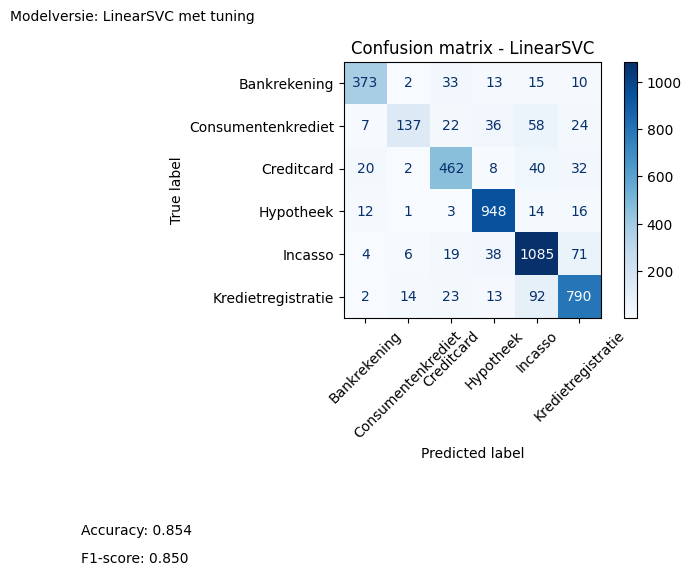

In [21]:
cm = confusion_matrix(y_test, y_pred_svc)
print(cm)
accuracy = accuracy_score(y_test, y_pred_svc)
f1 = f1_score(y_test, y_pred_svc, average='weighted')

print(f"Accuracy (LinearSVC): {accuracy:.3f}")
print(f"F1-score (weighted): {f1:.3f}")

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svc,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix - LinearSVC')
plt.suptitle("Modelversie: LinearSVC met tuning", fontsize=10, x=0.1, y=0.97)
plt.figtext(0.02, -0.1, f"Accuracy: {accuracy:.3f}", ha='left', va='top')
plt.figtext(0.02, -0.16, f"F1-score: {f1:.3f}", ha='left', va='top')
plt.gcf().tight_layout()
plt.savefig(
    "afbeeldingen/confusion_matrix_linearsvc_met_tuning.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


#### 5.6.5 ROC curves per productsector

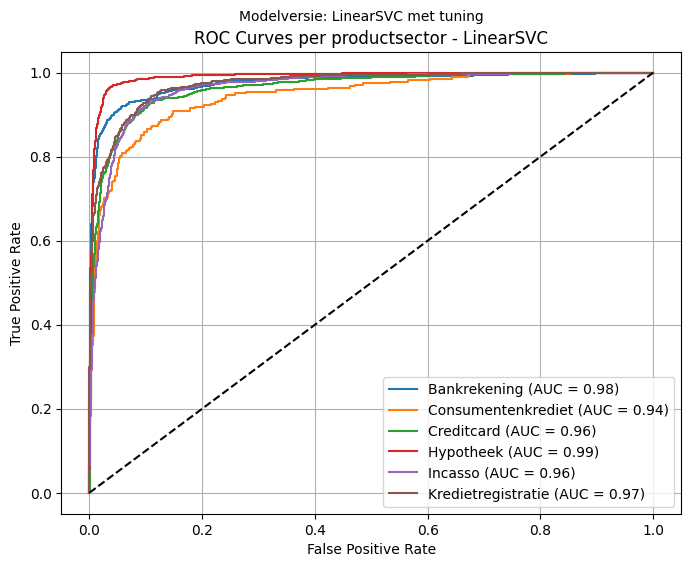

In [22]:
classes = best_svc['model'].classes_  # productsectoren uit het model

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    # binaire labels voor de huidige productsector
    y_binary = (y_test == class_name).astype(int)

    # scores voor deze klasse uit decision_function
    if y_scores_svc.ndim == 1:
        scores = y_scores_svc
    else:
        scores = y_scores_svc[:, i]

    fpr, tpr, _ = roc_curve(y_binary, scores)
    auc_score = roc_auc_score(y_binary, scores)

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], '--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per productsector - LinearSVC')
plt.suptitle("Modelversie: LinearSVC met tuning", fontsize=10, y=0.95)
plt.legend()
plt.grid(True)
plt.savefig(
    "afbeeldingen/linearsvc_roc_curves_met_tuning.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()
